### 01 - Instalar as bibliotecas

In [ ]:
!pip install lasio welly pandas matplotlib seaborn -q

### 02 - Importar a bibliotecas

In [ ]:
import lasio
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 03 - Carregar o arquivo LAS

In [ ]:
las = lasio.read('/content/1044034903.las')

##### Super Dica:
Não confiar em nomes esperados vindos do arquivo LAS. Confiar somente no que o arquivo realmente traz.

Pois cada fornecedor pode colocar o seu próprio mneumonico/sigla...
Não é muito comum, más acontece...

### 04 - Inspeção inicial (essencial)

In [ ]:
print('=' * 80)

print(las.well)

print('=' * 80)

# listar cabecalho
print(las.header)

print('=' * 80)

# listar curvas
print(las.curves)

print('=' * 80)

# converter para dataframe (pandas)
df_las = las.df()

# resertar indice (profundidade vira coluna)
df_las.reset_index(inplace=True)

# renomar coluna profundidade
df_las.rename(columns={'DEPT': 'DEPTH'}, inplace=True)

# renomear coluna porosidade de netron
df_las.rename(columns={'NPHI': 'NPOR'}, inplace=True)

print(df_las.head())
print(df_las.info())

Mnemonic  Unit  Value                  Description           
--------  ----  -----                  -----------           
STRT      F     450.0                  START DEPTH           
STOP      F     1460.0                 STOP DEPTH            
STEP      F     0.5                    STEP                  
NULL            -999.0                 NULL VALUE            
COMP            BILL BARRETT CORP.     COMPANY               
LEAS            HELMAN, P.             LEASE NAME            
WELL            13-24                  WELL NUMBER           
FLD             GOODLAND NIOBRARA GAS  FIELD                 
LOC             24-06S-40W             LOCATION              
LOC1            NW NE NW SW            QUARTERS              
LOC2            2514 FSL 782 FWL       FOOTAGES              
SEC             24                     SECTION               
TWP             06S                    TOWNSHIP              
RANG            40W                    RANGE                 
CNTY    

### 05 - Limpeza (critico)
Obs: Arquivo LAS sempre vem com dados "sujos"

In [ ]:
# substituir valores invalidos (-999, -999.25 etc)
df_las = df_las.replace([-999, -999.25, -9999], np.nan)

# remover linhas com muitos NaNs
df_las = df_las.dropna(thresh=int(df_las.shape[1] * 0.6))

### 06 - Visualização rápida

             DEPTH         CALI          SGR          CGR         POTA  \
count  2021.000000  2021.000000  2021.000000  2021.000000  2021.000000   
mean    955.000000     3.508793   142.850717    89.870708     0.031056   
std     291.778383     0.135149    35.196225    24.115788     0.006893   
min     450.000000     2.650000    79.500000    16.300000     0.010000   
25%     702.500000     3.480000   120.000000    89.600000     0.030000   
50%     955.000000     3.520000   127.500000    98.700000     0.033000   
75%    1207.500000     3.540000   161.100000   104.500000     0.036000   
max    1460.000000     5.050000   329.200000   130.300000     0.044000   

              THOR         URAN         DPHZ         PEF         NPOR  \
count  2021.000000  2021.000000  2021.000000  2021.00000  2021.000000   
mean      9.613093     6.828694    25.879579     3.50662    39.609184   
std       3.264708     5.484016     5.301380     0.51310     3.855706   
min      -0.250000     1.170000    11.780

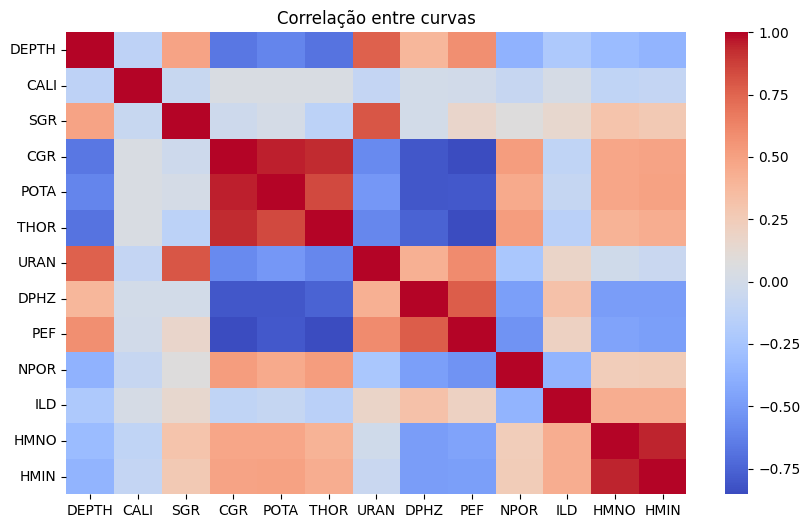

In [ ]:
# estatistica basica
print(df_las.describe())

# heatmap de correlacao
plt.figure(figsize=(10,6))
sns.heatmap(df_las.corr(), cmap='coolwarm')
plt.title('Correlação entre curvas')
plt.show()

### 07 - Log Plots (visual real de poço)

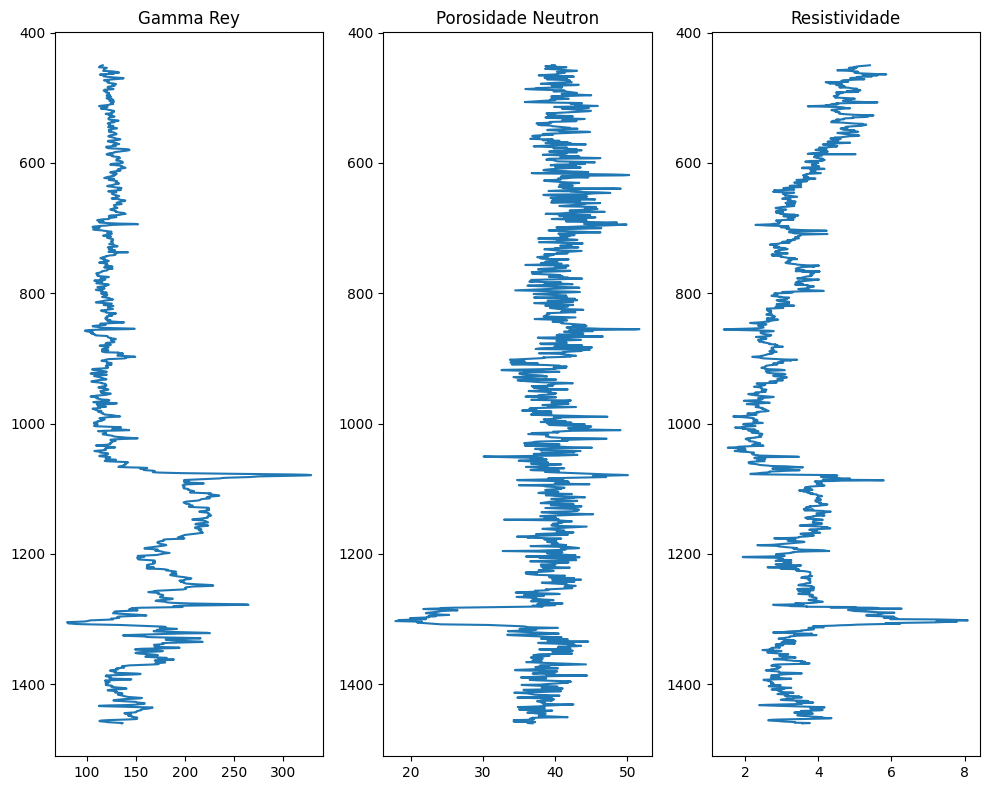

In [ ]:
plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.plot(df_las['SGR'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('Gamma Rey')

plt.subplot(1,3,2)
plt.plot(df_las['NPOR'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('Porosidade Neutron')

plt.subplot(1,3,3)
plt.plot(df_las['ILD'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('Resistividade')

plt.tight_layout()
plt.show()

---

### 07 - Engenharia de Atributos

### Criação de variáveis **Físicas**

---

### - Porosidade Média

<span style='color=orange;'>Porosidade média (PHI)</span>
É uma medida da quantidade de espaço vazio (poros) em uma rocha, expressa geralmente em porcentagem ou fração. É um bom indicador para descobrir petróleo porque o petróleo (e gás ou água) se acumula e flui através desses espaços porosos dentro da rocha. Quanto maior a porosidade, maior o potencial de armazenamento de hidrocarbonetos.

A unidade de medida para a porosidade é tipicamente em porcentagem (%) ou fração decimal (por exemplo, 0.20 para 20%).

os valores mínimos e máximos podem variar bastante dependendo do tipo de rocha. No entanto, geralmente se esperam:

* Valores Mínimos: Rochas com porosidade abaixo de 5% a 10% são geralmente consideradas de baixa porosidade e menos ideais para reservatórios de petróleo. Embora existam exceções, abaixo desse limiar, o fluxo de fluidos é muito limitado.

* Valores Máximos: Rochas com boa porosidade para reservatórios podem variar de 15% a 30%. Em casos de rochas muito porosas (como algumas areias não consolidadas), a porosidade pode até exceder 30% ou 40%. Valores muito altos podem indicar rochas com pouca compactação ou com espaços porosos grandes e bem conectados.

In [ ]:
# converter porosidades percentuais para fração
df_las['DPHZ_frac'] = df_las['DPHZ'] / 100.0
df_las['NPOR_frac'] = df_las['NPOR'] / 100.0

df_las['PHI'] = (df_las['DPHZ_frac'] + df_las['NPOR_frac']) / 2

### - Saturação aproximada (proxy simples)

A Saturação aproximada (proxy simples) é uma estimativa simplificada e indireta da saturação de fluidos em rochas. É um bom indicador para uma avaliação inicial e rápida, pois uma menor saturação de água (e, consequentemente, maior saturação de hidrocarbonetos) aponta para potencial de petróleo. O proxy simples em si não possui unidade de medida específica; a saturação de fluidos é tipicamente expressa em porcentagem (%) ou fração decimal (variando de 0 a 100% ou 0 a 1 para a saturação real).

Em geologia do petróleo, o termo "proxy simples" significa que estamos usando uma estimativa simplificada ou uma representação indireta para a saturação.

* Proxy: É algo que representa ou substitui outra coisa, especialmente para medir ou indicar algo que não pode ser medido diretamente ou com facilidade.

* Simples: Indica que essa representação ou estimativa é básica, descomplicada e talvez não tão precisa quanto métodos mais complexos, mas é útil para ter uma ideia rápida ou inicial.

Ou seja, estamos usando uma maneira fácil de estimar a saturação, sem a necessidade de cálculos ou dados mais elaborados que seriam exigidos para uma determinação mais exata.

In [ ]:
# resistividade em log
df_las['RES_LOG'] = np.log(df_las['ILD']).replace(0, np.nan)

### - Rigidez relativa (proxy físico simplificado)

A Rigidez relativa (proxy físico simplificado) é uma medida indireta da capacidade de deformação de uma rocha. Em geologia do petróleo, é utilizada como uma estimativa simplificada da elasticidade e resistência da rocha. Rochas mais rígidas podem indicar a presença de formações menos porosas ou com maior compactação, o que, em geral, não é um bom indicador para a descoberta de petróleo em grandes quantidades, pois o petróleo é encontrado em rochas porosas e permeáveis. No entanto, pode ser útil para identificar litologias específicas.

* Unidade de medida: Não possui uma unidade padrão diretamente associada a um "proxy físico simplificado" de rigidez. Medidas de rigidez mais formais, como o módulo de Young, são dadas em unidades de pressão (e.g., Pascal ou psi). No contexto de um "proxy", pode ser um valor adimensional ou derivado de outras curvas.

* Valores estimados mínimos e máximos: Para um proxy simplificado, esses valores podem variar muito dependendo das curvas de poço utilizadas para calculá-lo e da escala em que é interpretado. Não há uma faixa universalmente aceita para um "proxy físico simplificado" de rigidez.

In [ ]:
# rigidez relativa simplificada
df_las['RIGIDEZ_REL'] = 1 / (df_las['PHI'] + 0.01)

### - Índice de argila

O Índice de argila é uma medida da proporção de argila presente em uma rocha. Em geologia do petróleo, a argila é geralmente um mau indicador para a descoberta de petróleo.

* Por quê? Rochas com alto teor de argila tendem a ter baixa porosidade e permeabilidade, o que impede o acúmulo e o fluxo de hidrocarbonetos. Além disso, a argila pode reter água, dificultando a produção de petróleo.

* Unidade de medida: É geralmente expressa como uma fração decimal ou porcentagem (%).

Valores normalmente estimados (proxy simples):

* Mínimos: Próximos de 0 (baixa argila, potencial para reservatório).

* Máximos: Próximos de 1 (ou 100%) (alta argila, potencial reduzido para reservatório).

In [ ]:
GR_min = df_las['SGR'].min()
GR_max = df_las['SGR'].max()

df_las['VSH'] = (df_las['SGR'] - GR_min) / (GR_max - GR_min)
df_las['VSH'] = df_las['VSH'].clip(0, 1)

In [ ]:
print(df_las.head())

   DEPTH  CALI    SGR   CGR   POTA   THOR  URAN   DPHZ    PEF   NPOR   ILD  \
0  450.0   3.5  116.0  98.1  0.033  10.61  2.38  25.29  3.144  39.54  5.41   
1  450.5   3.5  115.1  96.0  0.033  10.55  2.49  25.59  3.180  40.03  5.33   
2  451.0   3.5  114.1  97.4  0.033  10.49  2.51  25.87  3.197  39.68  5.22   
3  451.5   3.5  113.1  96.6  0.033  10.44  2.39  26.40  3.197  38.65  5.11   
4  452.0   3.5  113.1  95.9  0.033  10.39  2.45  26.76  3.197  38.94  5.06   

   HMNO  HMIN   RES_LOG      PHI  RIGIDEZ_REL       VSH  DPHZ_frac  NPOR_frac  
0  4.59  4.10  1.688249  0.32415     2.992668  0.146175     0.2529     0.3954  
1  4.51  4.11  1.673351  0.32810     2.957705  0.142571     0.2559     0.4003  
2  4.44  4.12  1.652497  0.32775     2.960770  0.138566     0.2587     0.3968  
3  4.36  4.14  1.631199  0.32525     2.982849  0.134561     0.2640     0.3865  
4  4.24  4.02  1.621366  0.32850     2.954210  0.134561     0.2676     0.3894  


---

### 08 - NORMALIZAÇÃO (IMPORTANTE PARA FENICS / ML)

O objetivo principal é normalizar (escalar)  os dados para algoritmos de Machine Learning.

Muitos algoritmos de ML funcionam melhor ou convergem mais rapidamente quando as variáveis de entrada são escaladas para uma faixa comum, pois isso evita que atributos com valores maiores dominem o processo de aprendizado.

---

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['PHI', 'RES_LOG', 'RIGIDEZ_REL', 'VSH']

df_las[cols] = scaler.fit_transform(df_las[cols])

print(df_las.head)

<bound method NDFrame.head of        DEPTH  CALI    SGR   CGR   POTA   THOR   URAN   DPHZ    PEF   NPOR  \
0      450.0  3.50  116.0  98.1  0.033  10.61   2.38  25.29  3.144  39.54   
1      450.5  3.50  115.1  96.0  0.033  10.55   2.49  25.59  3.180  40.03   
2      451.0  3.50  114.1  97.4  0.033  10.49   2.51  25.87  3.197  39.68   
3      451.5  3.50  113.1  96.6  0.033  10.44   2.39  26.40  3.197  38.65   
4      452.0  3.50  113.1  95.9  0.033  10.39   2.45  26.76  3.197  38.94   
...      ...   ...    ...   ...    ...    ...    ...    ...    ...    ...   
2016  1458.0  3.25  120.1  46.1  0.020   5.45  10.46  28.65  3.981  37.23   
2017  1458.5  3.24  124.5  48.6  0.020   5.76  10.51  29.42  3.985  36.72   
2018  1459.0  3.25  131.7  51.2  0.022   6.06  10.62  30.34  3.997  36.21   
2019  1459.5  3.24  136.5  54.1  0.023   6.33  10.57  31.03  3.943  36.17   
2020  1460.0  3.24  135.5  56.5  0.023   6.50  10.54  30.14  3.823  36.85   

       ILD  HMNO  HMIN   RES_LOG       PHI  R

Dica: Plot rápido para verificar se está tudo coerente

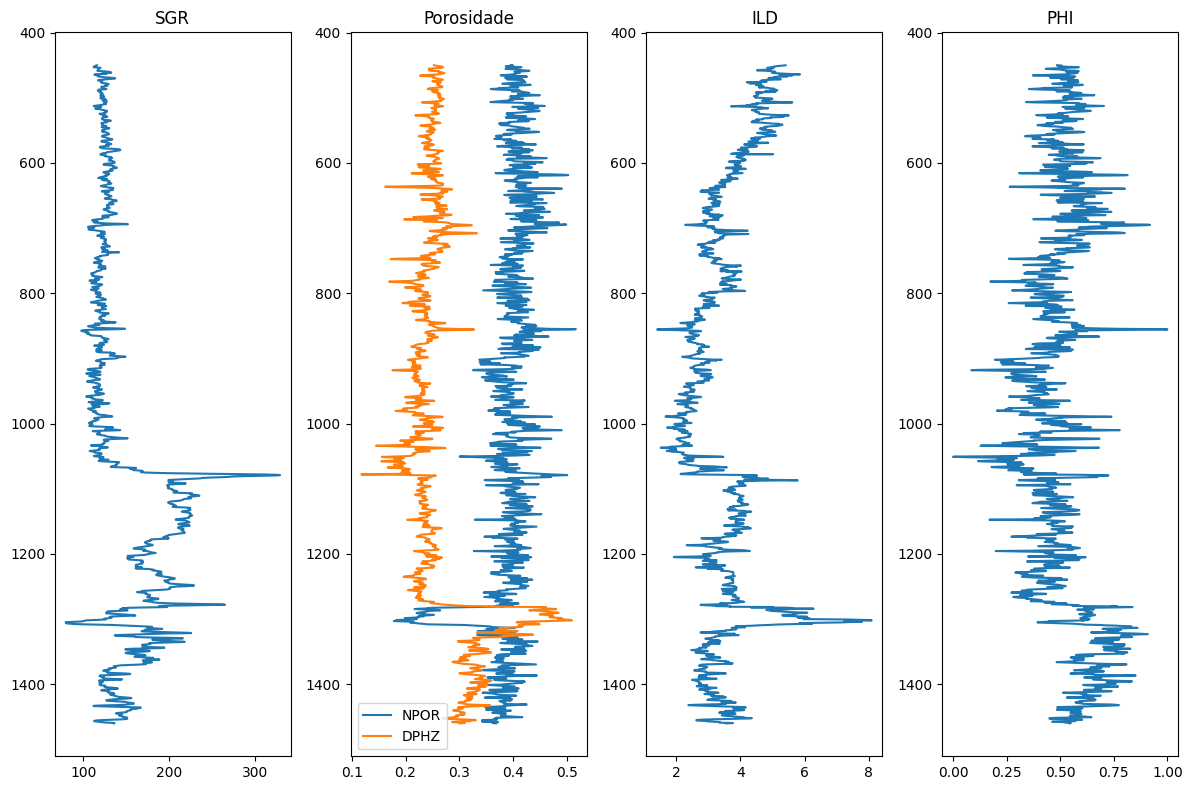

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(1,4,1)
plt.plot(df_las['SGR'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('SGR')

plt.subplot(1,4,2)
plt.plot(df_las['NPOR_frac'], df_las['DEPTH'], label='NPOR')
plt.plot(df_las['DPHZ_frac'], df_las['DEPTH'], label='DPHZ')
plt.gca().invert_yaxis()
plt.title('Porosidade')
plt.legend()

plt.subplot(1,4,3)
plt.plot(df_las['ILD'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('ILD')

plt.subplot(1,4,4)
plt.plot(df_las['PHI'], df_las['DEPTH'])
plt.gca().invert_yaxis()
plt.title('PHI')

plt.tight_layout()
plt.show()

---

### 09 - Exportar para Modelo Físico

---

In [ ]:
df_las_processado = df_las[['DEPTH', 'PHI', 'RES_LOG', 'RIGIDEZ_REL', 'VSH']]
df_las_processado.to_csv('las_processado.csv', index=False)

print(df_las_processado.head())
print('=' * 80)
print(df_las_processado.shape)

   DEPTH       PHI   RES_LOG  RIGIDEZ_REL       VSH
0  450.0  0.485210  0.769679     0.377061  0.146175
1  450.5  0.506649  0.761152     0.357136  0.142571
2  451.0  0.504749  0.749215     0.358883  0.138566
3  451.5  0.491180  0.737024     0.371465  0.134561
4  452.0  0.508820  0.731396     0.355145  0.134561
(2021, 5)


### Observação:
O que acabou de ser criado alimenta:

* FEniCS (PDEs)
* simulação de ondas
* poroelasticidade
* termoelasticidade

##### Nota: FEniCS (PDEs) é uma plataforma para resolver Equações Diferenciais Parciais (PDEs), que são equações matemáticas usadas para descrever fenômenos contínuos na física e engenharia (ex: fluxo de fluidos, transferência de calor), usando o Método dos Elementos Finitos.

---
### ??? score automático de qualidade de reservatório por profundidade, usando o próprio arquivo LAS ???
---

### A) Ideia central do score

Queremos responder:

“Em cada profundidade, quão promissora essa rocha parece como reservatório?”

Para isso vamos usar 3 sinais do arquivo LAS:

* SGR → limpeza da rocha → barro ou areia
* NPOR e DPHZ → porosidade → espaço para armazenar fluido
* ILD → indício do tipo de fluido → resistividade elétrica

### B) Lógica do score
O que ajuda a nota subir:
* Gamma Ray baixo
* Porosidade alta
* Resistividade alta

O que ajuda a nota cair:
* Gamma Ray alto
* Porosidade baixa
* Resistividade baixa

Então a lógica é esta:

score = melhor limpeza + maior porosidade + melhor fluido

Cada parte vai valer uma nota entre 0 e 1

No final:

score final = média ponderada dessas partes

E depois transformamos para 0 a 10

### C) A sacada importante: usar o próprio poço para calibrar

Em vez de usar limites fixos do mundo inteiro, vamos usar o próprio LAS

Por quê?

Porque cada poço pode ter:

* SGR naturalmente mais alto
* resistividade naturalmente mais baixa
* porosidade naturalmente mais alta

Então vamos normalizar com base no próprio dado

### D) Como cada componente será calculado

### D1) Limpeza da rocha

Usaremos o SGR.

Como queremos que SGR menor = melhor, fazemos assim:

clean_score = 1 - normalização(SGR)

Então:

* SGR baixo → nota perto de 1
* SGR alto → nota perto de 0

***GLOSSÁRIO:***

"normalização" se refere a um processo de escalonamento de valores para que fiquem dentro de uma faixa específica, geralmente entre 0 e 1. Isso é comumente feito utilizando técnicas como o MinMaxScaler, que transforma os dados de forma que o menor valor original se torne 0 e o maior valor original se torne 1, e todos os outros valores são ajustados proporcionalmente nesse intervalo. O objetivo é padronizar a escala da variável para que ela possa ser usada de forma consistente em cálculos de score.